# Notebook for the Specialized Amazon Financial Agent Demo

This notebook provides an interactive chat interface to interact with the agent. 
It connects to the FastAPI backend and uses Cognito for secure authentication.

- 1. Authentication (aws cognito)
- 2. Interactive chatbox, that only allowed after successfull authentication.
- 3. Additionally, this also provide some screenshots of the langfuse traces.

## 🔐 1. Authentication (Cognito)
Paste your **ID Token** or **Access Token** from Cognito below.

In [1]:
import hmac
import hashlib
import base64

import boto3
import requests
import json
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
from dotenv import load_dotenv
import os

# Load env variables
load_dotenv()

COGNITO_REGION = os.getenv("COGNITO_REGION")
COGNITO_CLIENT_ID = os.getenv("COGNITO_APP_CLIENT_ID")
COGNITO_CLIENT_SECRET = os.getenv("COGNITO_CLIENT_SECRET")

def get_secret_hash(username, client_id, client_secret):
    message = username + client_id
    dig = hmac.new(
        client_secret.encode('utf-8'),
        msg=message.encode('utf-8'),
        digestmod=hashlib.sha256
    ).digest()
    return base64.b64encode(dig).decode()


# --- design the buttons and the logging ---


email_input = widgets.Text(
    description="Email:",
    placeholder="teach42@gmail.com",
    layout={'width': '300px'}
)
passw_input = widgets.Password(
    description="Password:",
    placeholder="Your password",
    layout={'width': '300px'}
)
auth_button = widgets.Button(
    description="Login with Cognito",
    button_style='info',
    icon='key'
)
auth_output = widgets.Output()

def cognito_login(b):
    global TOKEN
    with auth_output:
        clear_output()
        try:
            secret_hash = get_secret_hash(
                email_input.value,
                COGNITO_CLIENT_ID,
                COGNITO_CLIENT_SECRET
            )

            client = boto3.client('cognito-idp', region_name=COGNITO_REGION)
            response = client.initiate_auth(
                AuthFlow='USER_PASSWORD_AUTH',
                AuthParameters={
                    'USERNAME': email_input.value,
                    'PASSWORD': passw_input.value,
                    'SECRET_HASH': secret_hash
                },
                ClientId=COGNITO_CLIENT_ID
            )
            TOKEN = response['AuthenticationResult']['AccessToken']
            print(f"✅ Successfully authenticated with Cognito!")
            print(f"👤 User: {email_input.value}")
            print(f"🔑 Token: {TOKEN[:40]}...")

            # Habilita el chat solo si ya existe
            try:
                send_button.disabled = False
                query_input.disabled = False
            except NameError:
                print("💡 Run the chat cell below to enable the chat.")

        except client.exceptions.NotAuthorizedException:
            print("❌ Wrong email or password.")
        except client.exceptions.UserNotFoundException:
            print("❌ User not found in Cognito pool.")
        except Exception as e:
            print(f"❌ Authentication failed: {str(e)}")

auth_button.on_click(cognito_login)
display(
    widgets.VBox([
        widgets.HTML("<h3>🔐 Cognito Authentication</h3>"),
        email_input,
        passw_input,
        auth_button,
        auth_output
    ])
)

## 💬 2. Chat with the Agent

In [2]:
import boto3
import json
import base64
import requests
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

# --- Configuración de AWS ---
client = boto3.client('bedrock-agentcore', region_name='us-east-1')
AGENT_RUNTIME_ARN = 'arn:aws:bedrock-agentcore:us-east-1:129987787606:runtime/tech42_agent_runtime-uhiOUmHwdI'

# --- Función para obtener datos del usuario desde el Token ---
def get_user_context(token):
    try:
        _, payload_b64, _ = token.split('.')
        payload_b64 += '=' * (-len(payload_b64) % 4) # Padding
        data = json.loads(base64.b64decode(payload_b64).decode('utf-8'))
        return {
            "user_name": data.get('cognito:username', 'User'),
            "email": data.get('email', 'N/A')
        }
    except:
        return {"user_name": "User", "email": "N/A"}

# --- Diseño de la Interfaz ---
chat_display = widgets.Output(layout={'border': '1px solid #ddd', 'height': '500px', 'overflow_y': 'scroll', 'padding': '10px'})
query_input = widgets.Text(placeholder='Write your question here...', layout={'width': '85%'})
send_button = widgets.Button(description='Send', button_style='primary', icon='paper-plane')

def on_send(b):
    query = query_input.value
    if not query or not TOKEN:
        return
    
    # 1. Obtener contexto del usuario desde el Token actual
    user_context = get_user_context(TOKEN)
    
    query_input.value = ''
    with chat_display:
        display(Markdown(f"### 👤 You\n{query}"))
        display(Markdown("### 🤖 Agent\n*Thinking and invoking runtime...*"))
    
    try:
        # 2. Preparar el Payload con Session Attributes
        payload = json.dumps({
            "prompt": query,
            "sessionAttributes": user_context
        })
        
        # 3. Llamada directa a Bedrock AgentCore
        # Usamos el mismo TOKEN como SessionId (ya que tiene > 33 chars y es único)
        response = client.invoke_agent_runtime(
            agentRuntimeArn=AGENT_RUNTIME_ARN,
            runtimeSessionId=TOKEN[-40:], # Usamos los últimos 40 chars del token como ID de sesión
            payload=payload
        )
        
        # 4. Procesar la respuesta (Streaming simulado por eventos)
        raw = response['response'].read().decode()
        events = raw.strip().split("\n\n")
        
        accumulated_response = ""
        
        for event in events:
            if event.startswith("data: "):
                data = json.loads(event[6:])
                
                # Manejo de Herramientas (Tools)
                messages = data.get("messages", [])
                for msg in messages:
                    # Si el agente está usando una herramienta
                    if msg.get("tool_calls"):
                        for tc in msg["tool_calls"]:
                            with chat_display:
                                display(Markdown(f"--- \n *🛠️ **Using tool:** `{tc['name']}`*"))
                    
                    # Si es respuesta de texto de la IA
                    if msg["type"] == "ai" and msg["content"]:
                        accumulated_response += msg["content"]
                        with chat_display:
                            clear_output(wait=True)
                            display(Markdown(f"### 👤 You\n{query}"))
                            display(Markdown(f"### 🤖 Agent\n{accumulated_response}"))
                            
    except Exception as e:
        with chat_display:
            display(Markdown(f"❌ **Error:** {str(e)}"))

send_button.on_click(on_send)

# Mostrar la UI
display(chat_display, widgets.HBox([query_input, send_button]))

Output(layout=Layout(border_bottom='1px solid #ddd', border_left='1px solid #ddd', border_right='1px solid #dd…

### 📋 Sample Queries:
1. **What is the stock price for Amazon right now?** (Uses Live Market Data)
2. **What were the stock prices for Amazon in Q4 last year?** (Uses Historical Market Data)
3. **Compare Amazon's recent stock performance to what analysts predicted in their reports** (Uses both RAG & Market Data)
4. **I’m researching AMZN, give me the current price and any relevant information about their AI business** (Uses both RAG & Market Data)
5. **What is the total amount of office space Amazon owned in North America in 2024?** (Uses RAG from Annual Report)

## Other Login+ Chat version

In [2]:
import boto3
import json
import base64
import hmac
import hashlib
import requests
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

from dotenv import load_dotenv
import os

# Load env variables
load_dotenv()


# ==========================================
# 1. Config (laoding from .env file)
# ==========================================
COGNITO_REGION = os.getenv("COGNITO_REGION")
COGNITO_CLIENT_ID = os.getenv("COGNITO_APP_CLIENT_ID")
COGNITO_CLIENT_SECRET = os.getenv("COGNITO_CLIENT_SECRET")
AGENT_RUNTIME_ARN = 'arn:aws:bedrock-agentcore:us-east-1:129987787606:runtime/tech42_agent_runtime-uhiOUmHwdI'

# Global variable for token
TOKEN = None

# ==========================================
# 2. useful function : hashing , get token
# ==========================================
def get_secret_hash(username, client_id, client_secret):
    message = username + client_id
    dig = hmac.new(
        client_secret.encode('utf-8'),
        msg=message.encode('utf-8'),
        digestmod=hashlib.sha256
    ).digest()
    return base64.b64encode(dig).decode()

def get_user_context(token):
    try:
        # Decodificar el Payload del JWT (ID Token)
        _, payload_b64, _ = token.split('.')
        payload_b64 += '=' * (-len(payload_b64) % 4)
        data = json.loads(base64.b64decode(payload_b64).decode('utf-8'))
        return {
            "user_name": data.get('cognito:username') or data.get('email', 'User'),
            "user_email": data.get('email', 'N/A')
        }
    except:
        return {"user_name": "User", "user_email": "N/A"}

# ==========================================
# 3. LOGIN Interface
# ==========================================
email_input = widgets.Text(description="Email:", placeholder="user@tech42.com")
passw_input = widgets.Password(description="Password:", placeholder="****")
auth_button = widgets.Button(description="Login with Cognito", button_style='info', icon='key')
auth_output = widgets.Output()

def cognito_login(b):
    global TOKEN
    with auth_output:
        clear_output()
        try:
            secret_hash = get_secret_hash(email_input.value, COGNITO_CLIENT_ID, COGNITO_CLIENT_SECRET)
            client_idp = boto3.client('cognito-idp', region_name=COGNITO_REGION)
            
            response = client_idp.initiate_auth(
                AuthFlow='USER_PASSWORD_AUTH',
                AuthParameters={
                    'USERNAME': email_input.value,
                    'PASSWORD': passw_input.value,
                    'SECRET_HASH': secret_hash
                },
                ClientId=COGNITO_CLIENT_ID
            )
            
            # Usamos IdToken porque contiene los claims (nombre, email)
            TOKEN = response['AuthenticationResult']['IdToken']
            print(f"✅ Successfully authenticated with Cognito!")
            send_button.disabled = False
            query_input.disabled = False
        except Exception as e:
            print(f"❌ Error: {str(e)}")

auth_button.on_click(cognito_login)

# ==========================================
# 4. INTERFACE FOR CHAT Y AGENTCORE LOGIC
# ==========================================
chat_display = widgets.Output(layout={'border': '1px solid #ddd', 'height': '400px', 'overflow_y': 'scroll', 'padding': '10px'})
query_input = widgets.Text(placeholder='Escribe tu pregunta...', layout={'width': '85%'}, disabled=True)
send_button = widgets.Button(description='Enviar', button_style='primary', icon='paper-plane', disabled=True)

client_agent = boto3.client('bedrock-agentcore', region_name='us-east-1')

def on_send(b):
    query = query_input.value
    if not query or not TOKEN:
        return
    
    # Extraer contexto del usuario del Token
    user_ctx = get_user_context(TOKEN)
    query_input.value = ''
    
    # Limpiar pantalla para la nueva interacción
    with chat_display:
        clear_output(wait=True)
        display(Markdown(f"### 👤 Usuario ({user_ctx['user_name']})\n{query}"))
        display(Markdown("### 🤖 Agente\n*Thinking...*"))
    
    try:
        # Prepare Payload with Session Attributes
        payload = json.dumps({
            "prompt": query,
            "sessionAttributes": user_ctx
        })
        
        # Invocar Runtime (SessionId debe ser > 33 chars)
        session_id = TOKEN[-40:].replace("_", "-") # Asegurar caracteres válidos
        
        response = client_agent.invoke_agent_runtime(
            agentRuntimeArn=AGENT_RUNTIME_ARN,
            runtimeSessionId=session_id,
            payload=payload
        )
        
        raw = response['response'].read().decode()
        events = raw.strip().split("\n\n")
        
        accumulated_text = ""
        
        for event in events:
            if event.startswith("data: "):
                data = json.loads(event[6:])
                messages = data.get("messages", [])
                
                for msg in messages:
                    # Detectar uso de Tools
                    if msg.get("tool_calls"):
                        for tc in msg["tool_calls"]:
                            with chat_display:
                                display(Markdown(f"*🛠️ Running tool: `{tc['name']}`...*"))
                    
                    # Acumular respuesta de la IA
                    if msg["type"] == "ai" and msg["content"]:
                        accumulated_text += msg["content"]
                        with chat_display:
                            clear_output(wait=True)
                            display(Markdown(f"### 👤 User ({user_ctx['user_name']})\n{query}"))
                            display(Markdown(f"### 🤖 Agent \n{accumulated_text}"))
                            
    except Exception as e:
        with chat_display:
            display(Markdown(f"❌ **Error from Runtime:** {str(e)}"))

send_button.on_click(on_send)

# ==========================================
# 5. DESPLEGAR TODO
# ==========================================
display(
    widgets.VBox([
        widgets.HTML("<h2>🚀 Tech42 AgentCore Shell</h2>"),
        email_input, passw_input, auth_button, auth_output,
        widgets.HTML("<hr>"),
        chat_display, 
        widgets.HBox([query_input, send_button])
    ])
)

## 3. Observability screenshots Langfuse

- trace example screenshot.

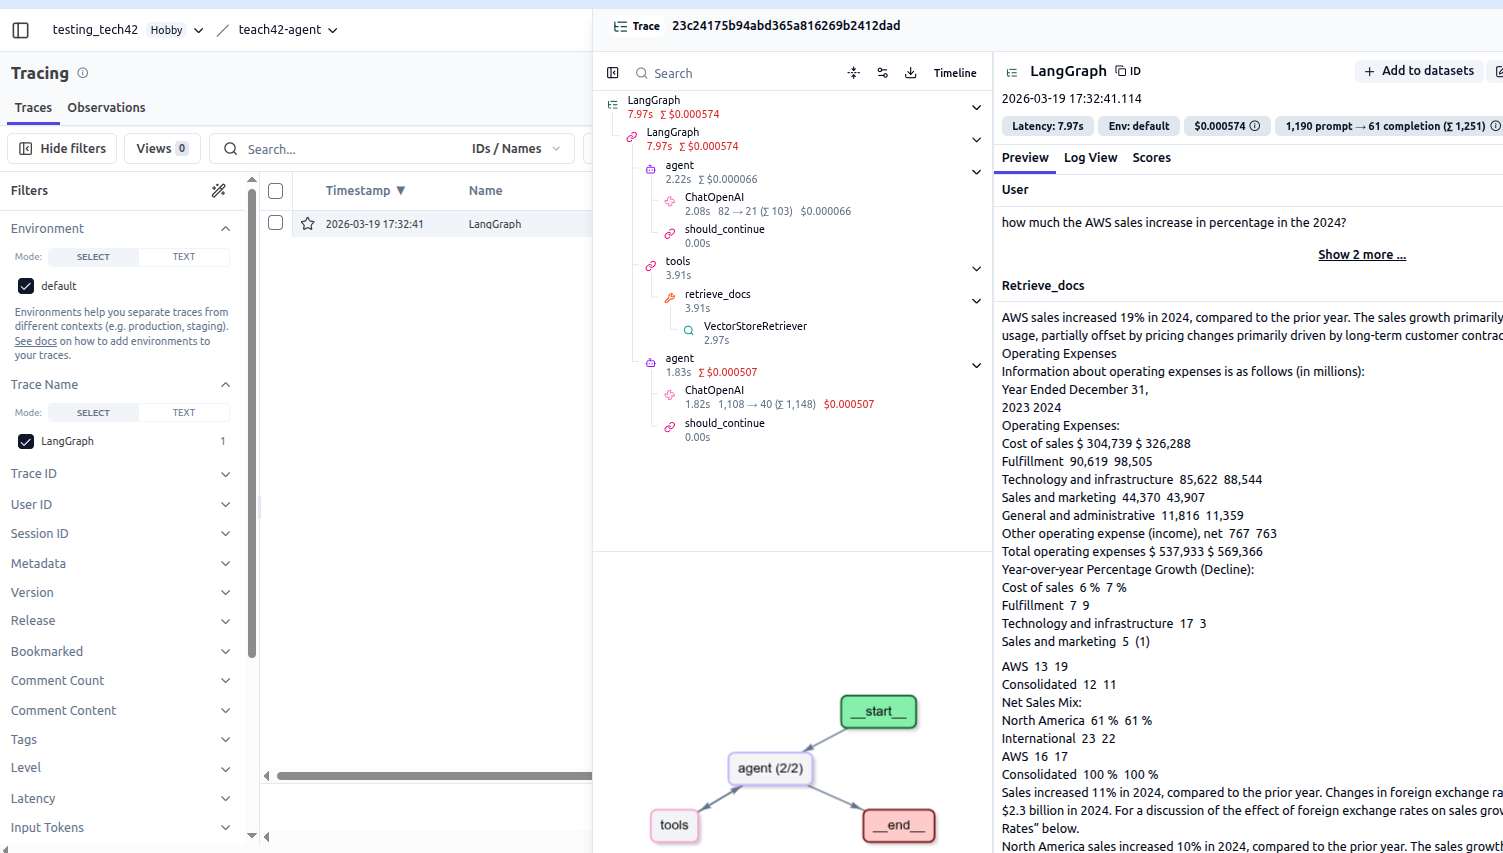

In [4]:
from IPython.display import Image, display

display(Image(filename="tracing_langfuse01.png"))